# [1교시]

1. Figure와 Axex 이해하기

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 한글 폰트 설정 (WINDOWS)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 데이터 로드 : 자동차 연비 데이터
mpg = sns.load_dataset("mpg")
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


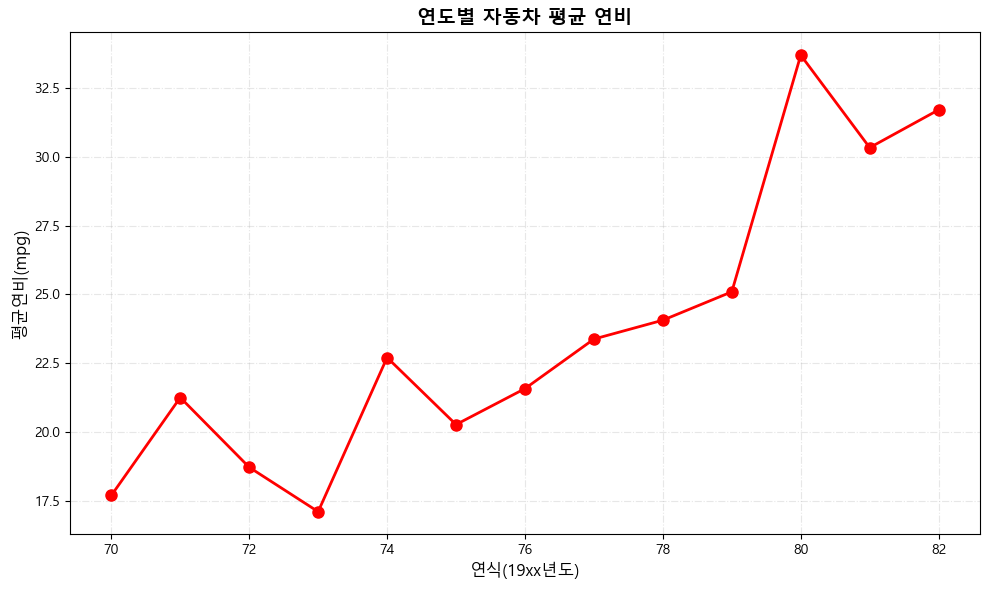

In [6]:
# 연도별 평균 연비 계산
yealy_mpg = mpg.groupby('model_year')['mpg'].mean()

# 객체지향 방식
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(yealy_mpg.index, yealy_mpg.values,
        marker = 'o', linewidth=2, markersize=8, color='r')

ax.set_xlabel('연식(19xx년도)', fontsize=12)
ax.set_ylabel('평균연비(mpg)', fontsize=12)
ax.set_title('연도별 자동차 평균 연비', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='-.')
plt.tight_layout()
plt.show()
# 인사이트: 1970년대 중반부터 연비가 급격히 개선 -> 오일쇼크 이후 연비 규제 강화 영향

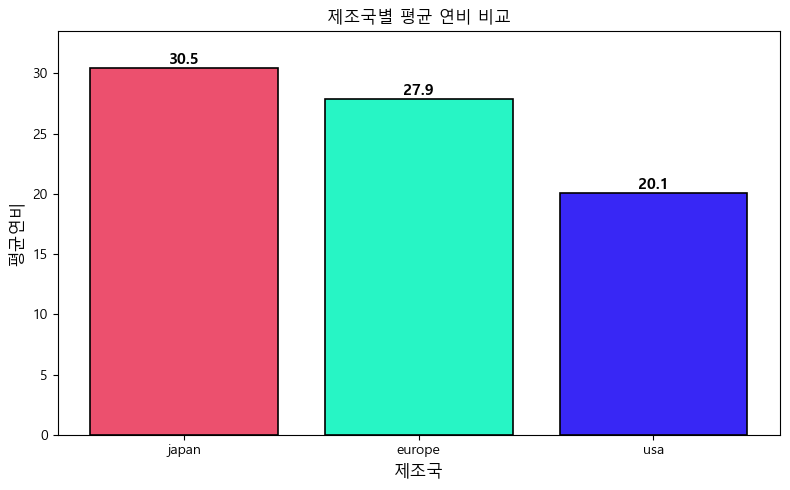

In [7]:
# 선그래프 : 연속적 흐름(연도별같은 시계열 차트), # 막대그래프 : 객체별 비교(비교할 상대가 있는 범주형 차트)
# 제조국(origin)별 평균 연비 mpg
origin_mpg = mpg.groupby('origin')['mpg'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

# 색상은 팔레트 색상표의 코드를 지원한다.
bars = ax.bar(origin_mpg.index, origin_mpg.values, color =['#ec506e', '#27f5c5', '#3827f5'],
       edgecolor = 'black', linewidth = 1.2)

# 막대 위에 수치 표시
for bar in bars:
    height = (bar.get_height())
    ax.text(bar.get_x() + bar.get_width()/2, height, 
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('제조국', fontsize = 12)
ax.set_ylabel('평균연비', fontsize = 12)
ax.set_title('제조국별 평균 연비 비교')
ax.set_ylim(0, origin_mpg.max()*1.1)
plt.tight_layout() 
plt.show()

# 인사이트: 일본(japan)차량이 평균 30.5mpg로 가장 효율적 -> 소형차 중심 전략

# [2교시]

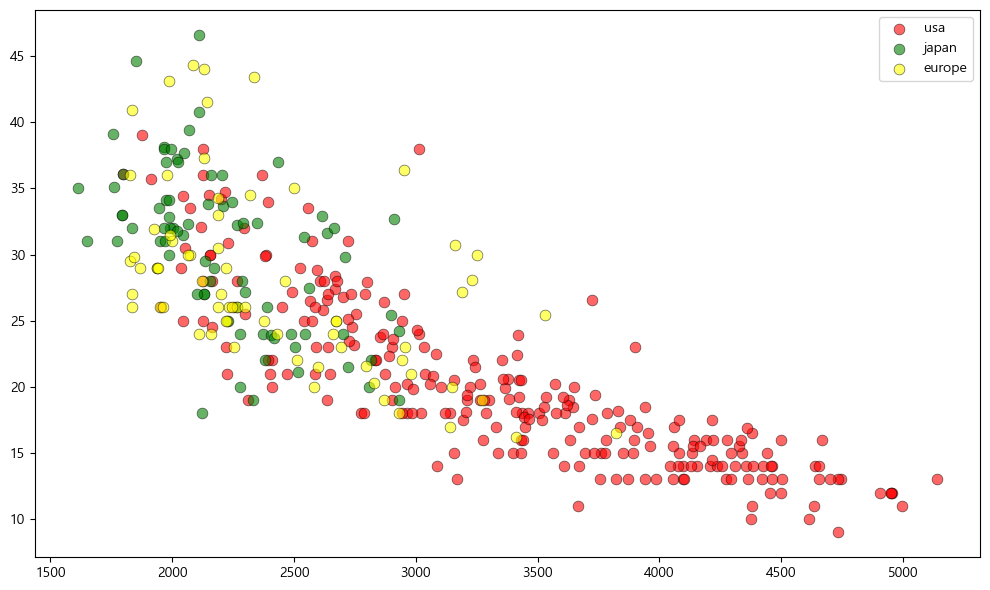

In [8]:
# 차량 무게와 연비는 어떤 관계일까?
fig, ax = plt.subplots(figsize=(10, 6))

# new_mpg = mpg.sort_values(by=['weight'])[['weight', 'mpg']]
# ax.scatter(new_mpg['weight'], new_mpg['mpg'])
# ax.plot()

# 제조국별로 색상 구분
colors ={'usa' : 'red', 'japan' : 'green', 'europe' : 'yellow'}
for origin, color in colors.items():
    mask = mpg['origin'] == origin
    ax.scatter(mpg[mask]['weight'], mpg[mask]['mpg'], c=color, label=origin,
               alpha=0.6, s=60, edgecolors='black', linewidths=0.5)
# 범례    
ax.legend()

plt.tight_layout()
plt.show()

# 인사이트: 강한 음의 상관관계 확인 - 무게가 1000lbs 증가시 연비 약 10mpg 감소
# 일본 차량군이 좌상단(가볍고 연비 좋음)에 집중 -> 경량화 전략의 효과

# 스타일 커스터마이징
## 색상, 마커, 선 스타일 조합으로 가독성 향상

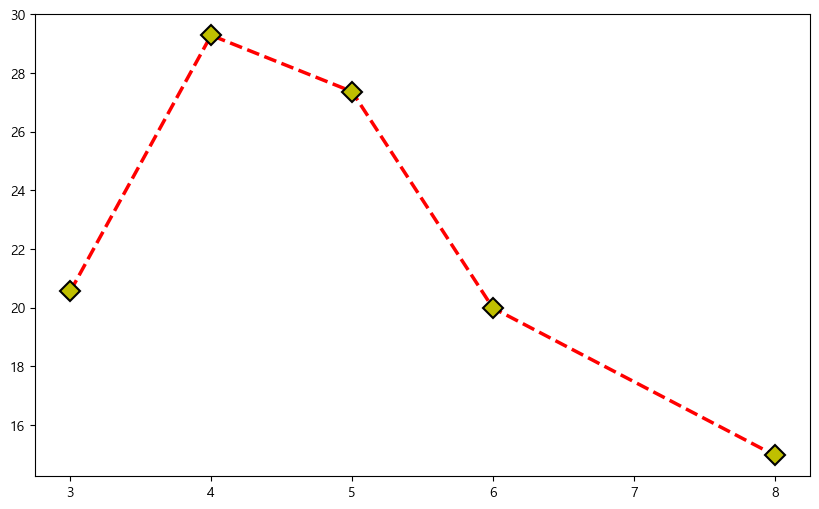

In [9]:
# 실린더 수별 연비 분포
cylinder_groups = mpg.groupby('cylinders')['mpg'].mean()
fig, ax = plt.subplots(figsize=(10, 6))

# 다양한 마커와 선 스타일
ax.plot(cylinder_groups.index, cylinder_groups.values,
        marker = 'D', linestyle = '--', linewidth=2.5,
        markersize=10, color='r', markerfacecolor='y',
        markeredgecolor='black', markeredgewidth=1.5)

plt.show()

# 인사이트: 실린더 수와 연비는 반비례 관계 - 8기통 차량은 4기통 대비 연비 50% 수준

------------

In [10]:
# 데이터 분포

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 한글 폰트 설정 (WINDOWS) - 글자가 깨지지않도록 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [12]:
# 데이터 로드 mpg
mpg = sns.load_dataset('mpg')
print(f'전체데이터 : {len(mpg)}')

# mpg의 기술통계 확인
mpg.describe()

전체데이터 : 398


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


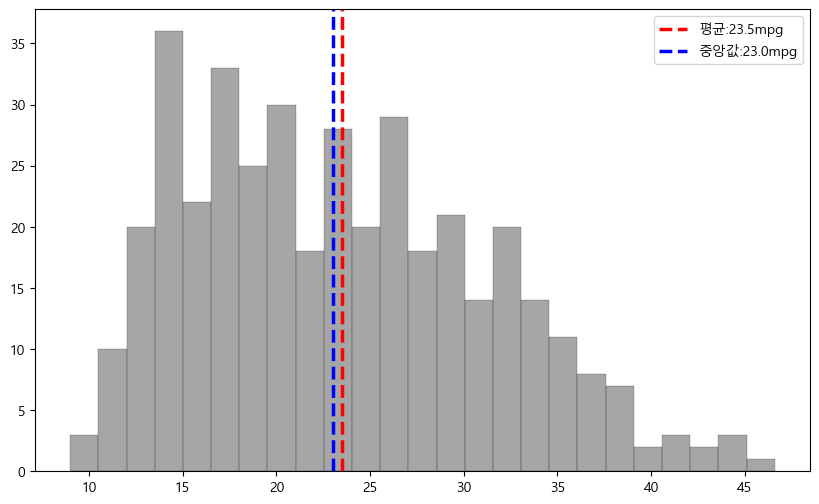

In [13]:
# 연비는 정규분포를 따를것인가?
# histogram 
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(mpg['mpg'], bins=25, edgecolor='black', color='gray', alpha=0.7, linewidth=0.2)
# 평균선 추가
mean_mpg = mpg['mpg'].mean()
ax.axvline(mean_mpg, color = 'r', linestyle= '--', linewidth=2.5, label=f'평균:{mean_mpg:.1f}mpg')
# 중앙선 추가
median_mpg = mpg['mpg'].median()
ax.axvline(median_mpg, color = 'b', linestyle= '--', linewidth=2.5, label=f'중앙값:{median_mpg:.1f}mpg')

ax.legend()

# 정규분포는 대칭성을 가져야 한다
# 평균 = 중앙값 = 최빈값
# 좌우가 대칭인 종 모양이 이상적 모습이다.

# 평균 > 중앙값   --> 우측꼬리가 존재(고연비 차량이 존재) --> 정규분포가 아님
# 10~20에 집중   --> 저연비 차량 비중이 높다

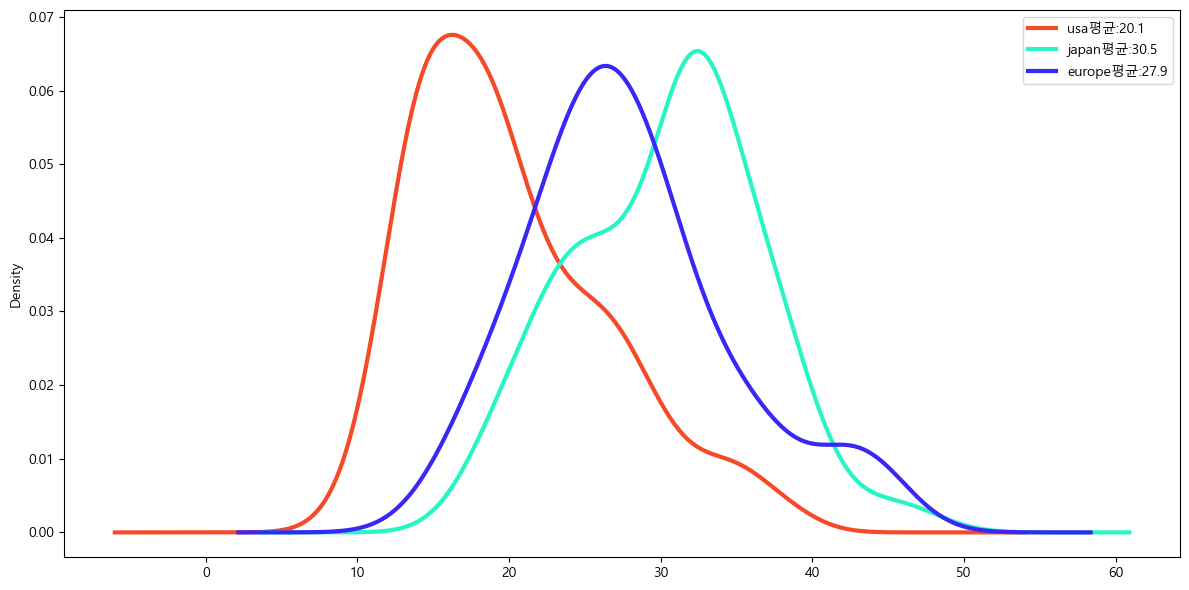

In [14]:
# 밀도: 부드러운 분포 곡선이라 생각하면 된다
# 국가별 연비 분포
colors = {
'usa' :'#F54927',
'japan': '#27F5C5',
'europe':'#3827F5'
}
fig, ax = plt.subplots(figsize=(12, 6))
for origin, color in colors.items():
    data = mpg['origin'] == origin
    data = mpg[data]['mpg']
    data.plot.kde(ax=ax, color=color, linewidth=3, label=f'{origin}평균:{data.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

# [3교시]

In [15]:
## zip[], []: 1:1로 묶어준다
# for dict(zip(['a', 'b', 'c'], [10, 20, 30]))

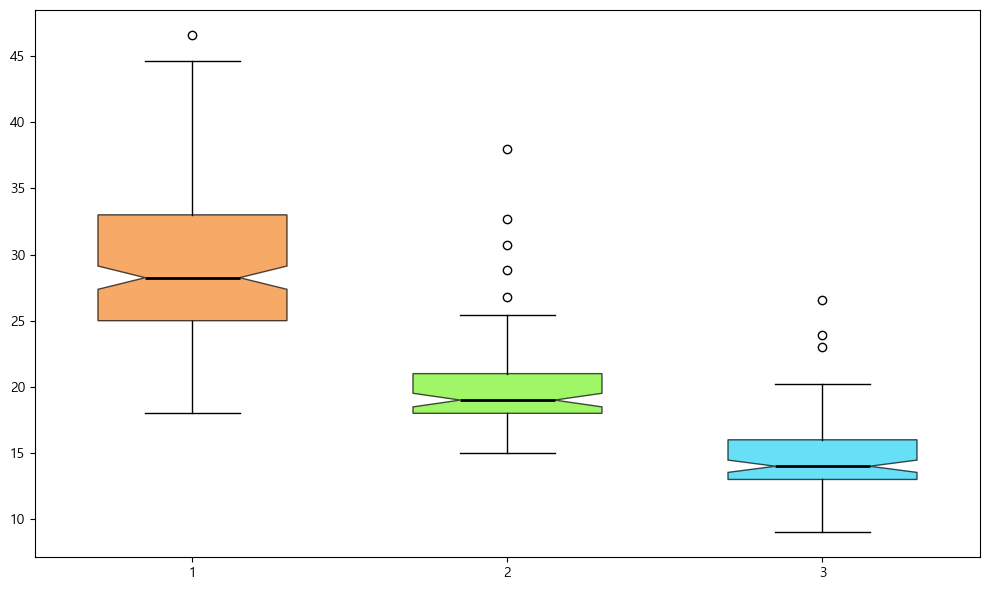

4기통 - 중앙값: 28.2 IQR:8.000000           이상치개수 : 1
6기통 - 중앙값: 19.0 IQR:3.000000           이상치개수 : 5
8기통 - 중앙값: 14.0 IQR:3.000000           이상치개수 : 3


In [16]:
# boxplot : 이상치, 사분위수
# 실린더 수량별로 연비 편차가 얼마나 다를까?
fig, ax = plt.subplots(figsize=(10, 6))

# mpg['cylinders'].value_counts()

# 특정 객체만 추출, 불린형 인덱스
mpg_clean = mpg[mpg['cylinders'].isin([4, 6, 8])].copy()

box_data = [mpg_clean[mpg_clean['cylinders'] == cyl]['mpg'] for cyl in [4, 6, 8]]
bp = ax.boxplot(box_data, label=['4기통', '6기통', '8기통'], patch_artist=True, notch=True, widths=0.6)

# box 색상
colors = ['#F58727', '#76F527', '#27D3F5']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 중앙값선 강조
for median in bp['medians']:
    median.set(color='black', linewidth=2)

plt.tight_layout()
plt.show()

# 통계요약
for cyl in [4, 6, 8]:
    data = mpg_clean[mpg_clean['cylinders'] == cyl]['mpg']
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3-q1
    print(f'{cyl}기통 - 중앙값: {data.median():.1f} IQR:{iqr:1f} \
          이상치개수 : { len(data[(data > q3+1.5*iqr) | (data < q1 - 1.5*iqr)] ) }' )

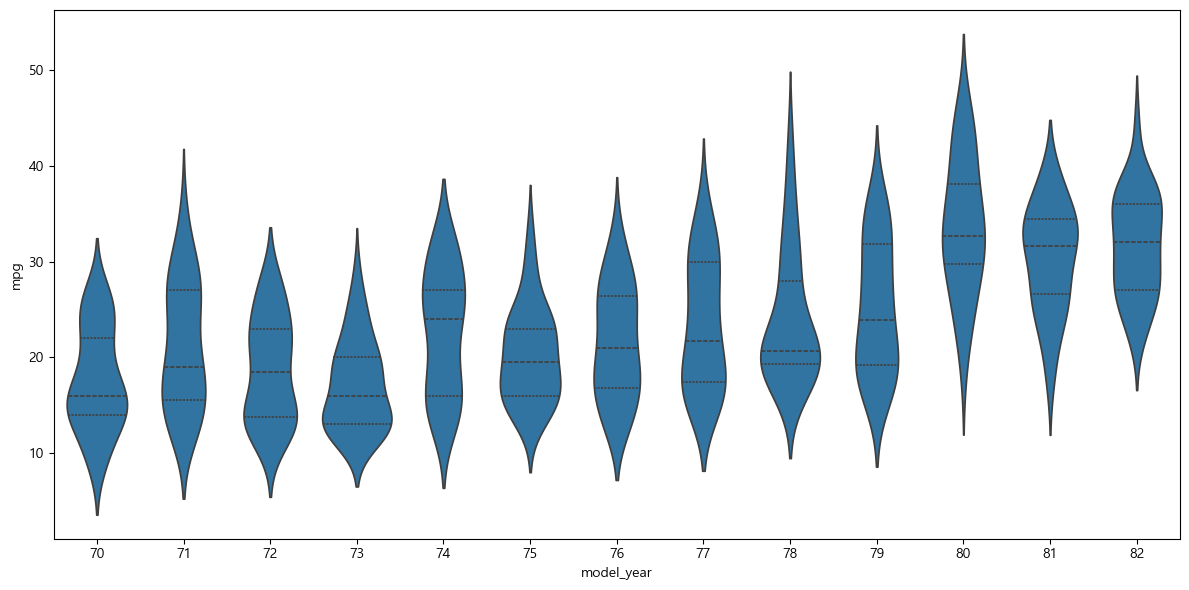

In [17]:
# violineplot 분포형태
# 연식에 따라 연비 분포가 어떻게 진화했는지?
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=mpg, x='model_year', y='mpg', ax=ax, inner='quartitle')
plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28468\3502330559.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data_weight, labels=['USA', 'Japan', 'Europe'],


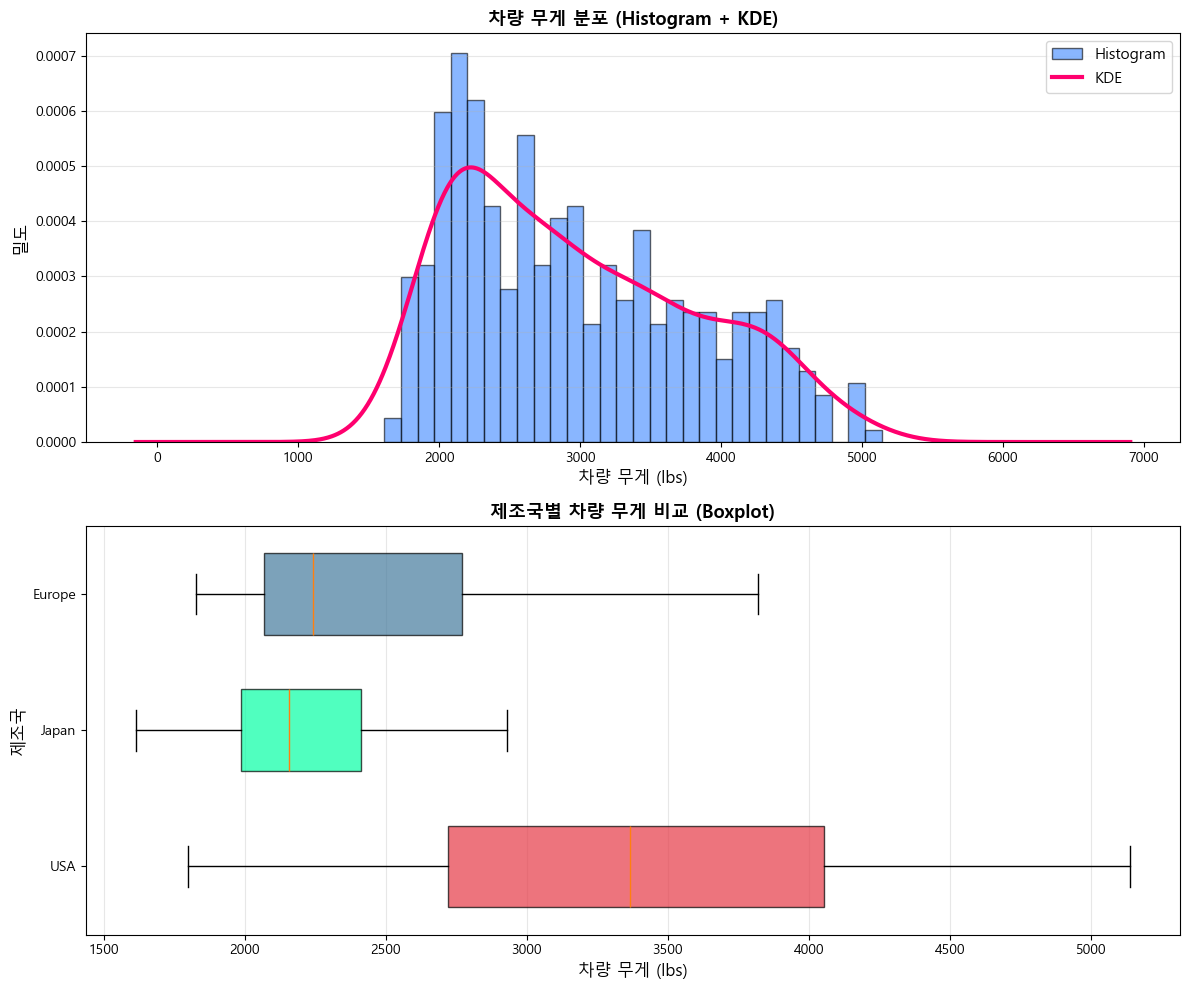

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 상단: Histogram + KDE
axes[0].hist(mpg['weight'], bins=30, edgecolor='black', 
             color='#3A86FF', alpha=0.6, density=True, label='Histogram')

mpg['weight'].plot.kde(ax=axes[0], color='#FF006E', linewidth=3, label='KDE')

axes[0].set_xlabel('차량 무게 (lbs)', fontsize=12)
axes[0].set_ylabel('밀도', fontsize=12)
axes[0].set_title('차량 무게 분포 (Histogram + KDE)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# 하단: Boxplot (제조국별)
box_data_weight = [mpg[mpg['origin'] == o]['weight'] for o in ['usa', 'japan', 'europe']]
bp = axes[1].boxplot(box_data_weight, labels=['USA', 'Japan', 'Europe'],
                     patch_artist=True, vert=False, widths=0.6)

for patch, color in zip(bp['boxes'], ['#E63946', '#06FFA5', '#457B9D']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xlabel('차량 무게 (lbs)', fontsize=12)
axes[1].set_ylabel('제조국', fontsize=12)
axes[1].set_title('제조국별 차량 무게 비교 (Boxplot)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 💡 인사이트: 미국 차량 중앙값 3,500lbs vs 일본 2,200lbs → 약 1,300lbs(60%) 차이
# 💡 일본 차량의 낮은 무게가 높은 연비의 핵심 요인

# [4교시]

seaborn 범주형 데이터 시각화

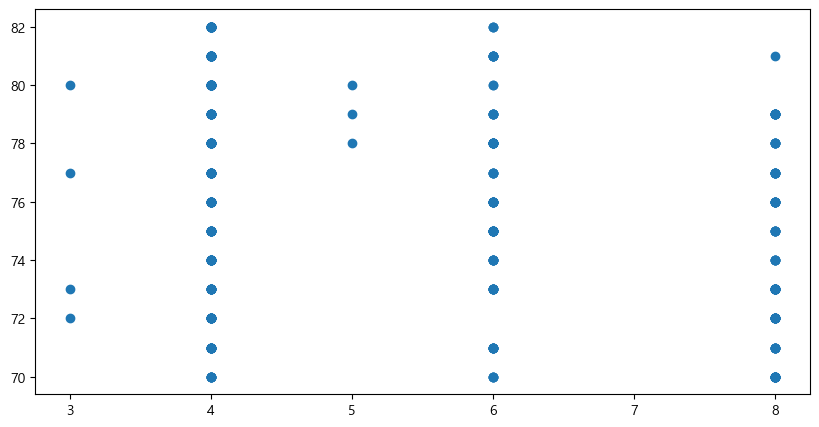

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset('mpg')
fig, ax = plt.subplots(figsize=(10, 5))
#ax.scatter(data['cylinders'], data['model_year'])

sns.scatterplot()

In [43]:
# Titanic 데이터 로드
titanic = sns.load_dataset('titanic')

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


class
Third     491
First     216
Second    184
Name: count, dtype: int64


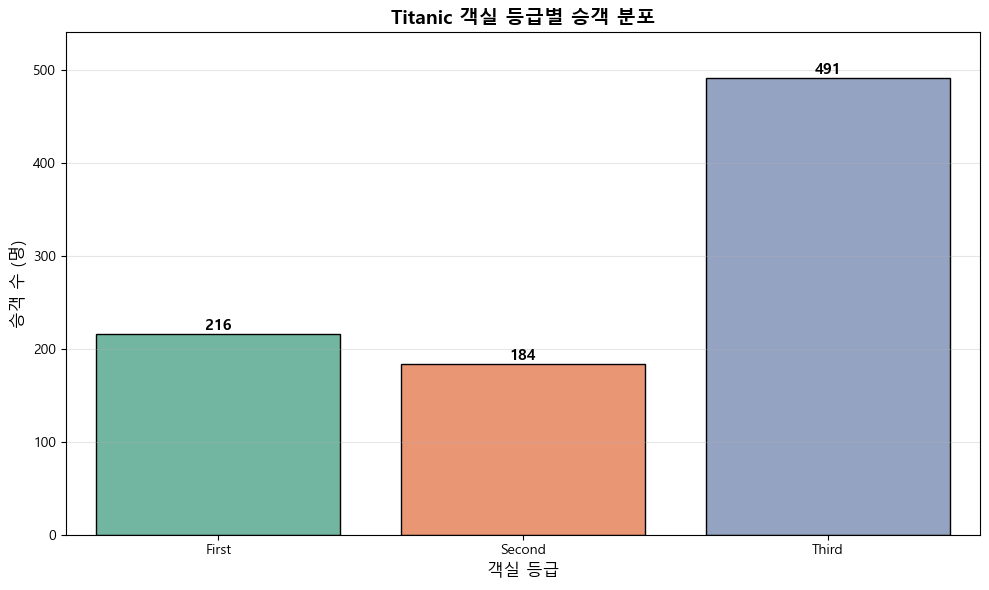

In [60]:
# countplot: 범주별 빈도수
# 승객 등급별 인원 분포는?

fig, ax = plt.subplots(figsize=(10, 6))
print(titanic['class'].value_counts())

# countplot 생성
# countplot은 개수를 세는거기 때문에 y값은 없다.
sns.countplot(data=titanic, x='class', ax=ax, palette='Set2', edgecolor='black', hue='class')

# 막대 위 수치 표시
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold')


ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('승객 수 (명)', fontsize=12)
ax.set_title('Titanic 객실 등급별 승객 분포', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, titanic['class'].value_counts().max()*1.1)

plt.tight_layout()
plt.show()

In [ ]:
# 각 객실 등급별 탑승 분포률 확인

print(titanic['class'].value_counts()/len(titanic))

class
Third     0.551066
First     0.242424
Second    0.206510
Name: count, dtype: float64


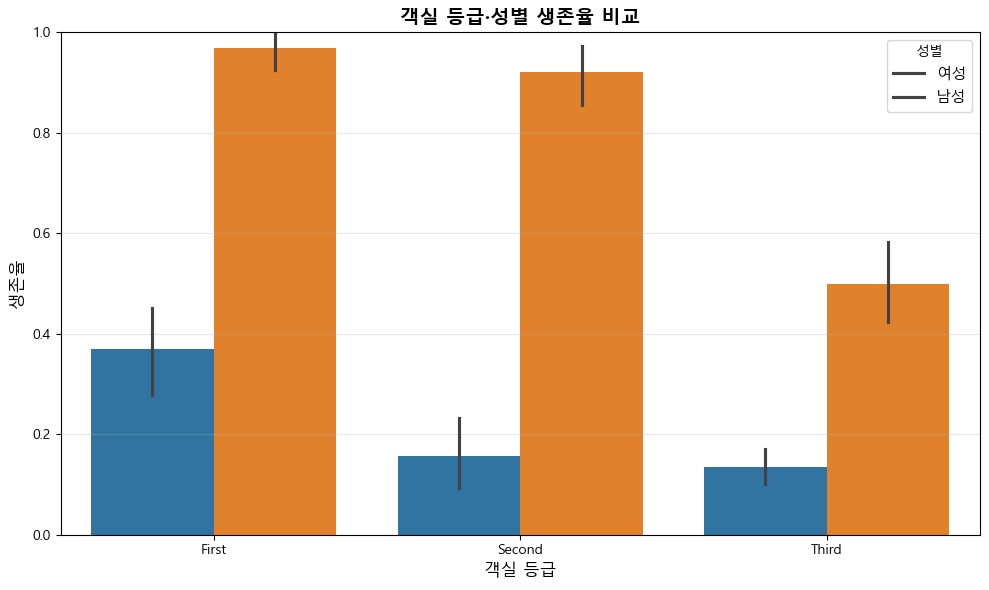

In [82]:
# 성별, 등급별 생존율 차이는?
fig, ax = plt.subplots(figsize=(10, 6))


sns.barplot(data=titanic, x='class', y='survived', hue = 'sex')

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('생존율', fontsize=12)
ax.set_title('객실 등급·성별 생존율 비교', fontsize=14, fontweight='bold')
ax.legend(title='성별', labels=['여성', '남성'], fontsize=11)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])

# 통계 확인
# survival_by_class_sex = titanic.groupby(['class', 'sex'])['survived'].mean()


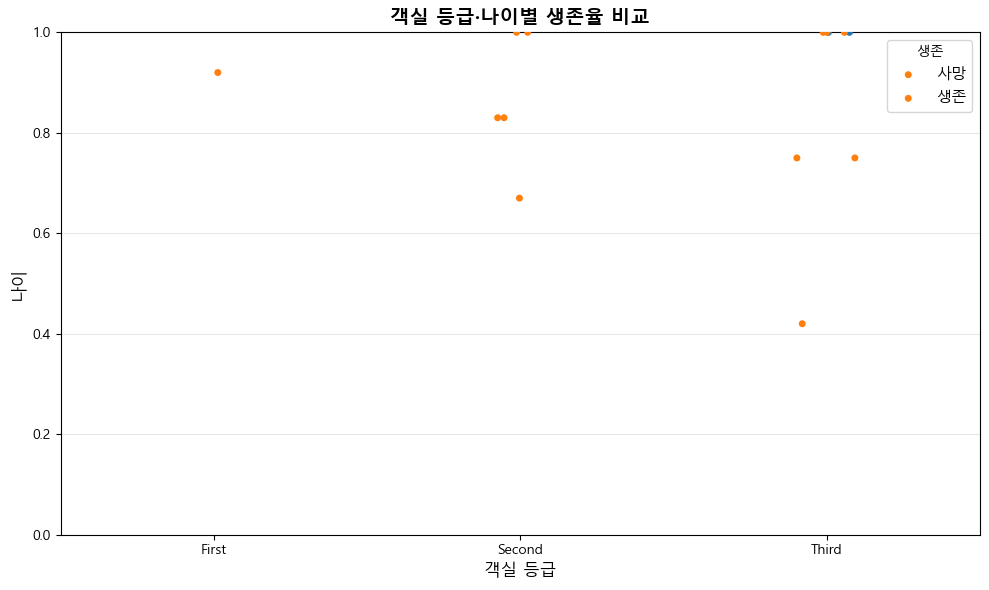

In [84]:
# 나이 분포가 생존률에 영향을 미쳤나?

fig, ax = plt.subplots(figsize=(10, 6))

# Stripplot 생성
sns.stripplot(data=titanic, x='class', y='age', hue='survived', ax=ax)

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('나이', fontsize=12)
ax.set_title('객실 등급·나이별 생존율 비교', fontsize=14, fontweight='bold')
ax.legend(title='생존', labels=['사망', '생존'], fontsize=11)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])

# 통계 확인
# survival_by_class_sex = titanic.groupby(['class', 'sex'])['survived'].mean()


c:\miniconda\envs\base_stream\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 28.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\miniconda\envs\base_stream\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 65.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\miniconda\envs\base_stream\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\miniconda\envs\base_stream\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\miniconda\envs\base_stream\Lib\site-packages\seaborn\categorical.py:3399: UserWarn

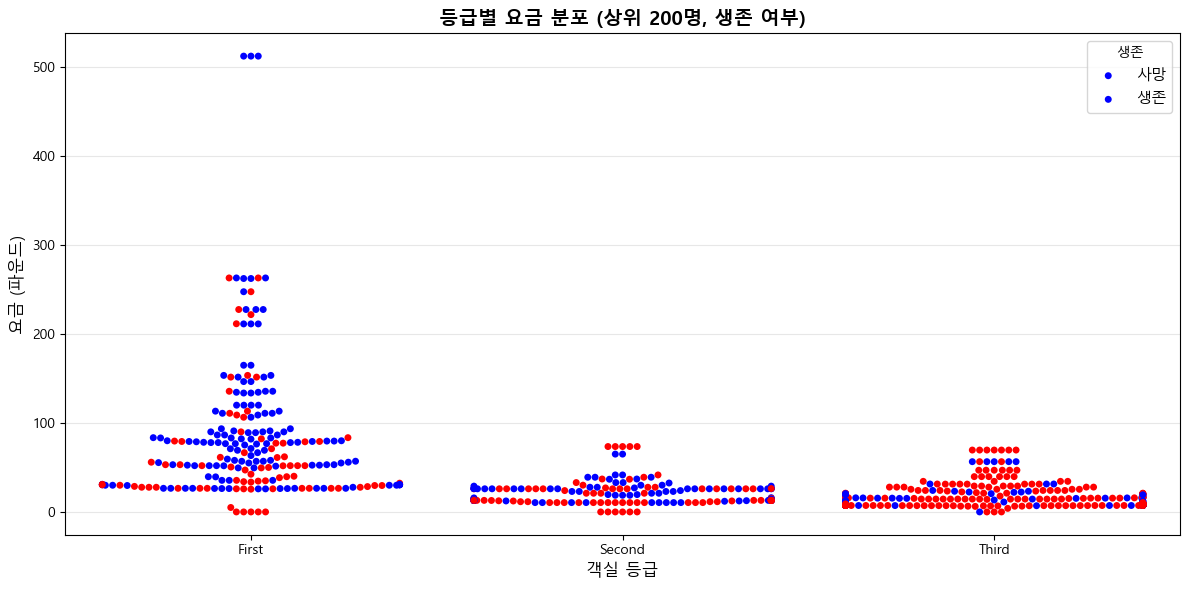

In [94]:
## swarmplot: 겹치지 않는 선점도

fig, ax = plt.subplots(figsize=(12, 6))

# 요금 상위 200명만 (가독성 위해)
titanic_fare = titanic.nlargest(200, 'fare')

# Swarmplot 생성
sns.swarmplot(data=titanic, x='class', y='fare', hue='survived', ax=ax,
              palette={0 : 'red', 1 : 'blue'},
              edgecolor='black', size=5)

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('요금 (파운드)', fontsize=12)
ax.set_title('등급별 요금 분포 (상위 200명, 생존 여부)', fontsize=14, fontweight='bold')
handles, labels = ax.get_legend_handles_labels()
ax.legend(title='생존', labels=['사망', '생존'], fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#  인사이트: 1등급 고액 요금 승객 대부분 생존 → 경제력이 구명보트 접근성과 연결
#  3등급은 요금 차이가 작지만 생존율 편차 큼 → 다른 요인(위치, 나이) 영향

# [5교시]

In [98]:
print(titanic.head())
titanic.info()

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28468\993424658.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels([f'{int(y*100)}%' for y in axes[1].get_yticks()])


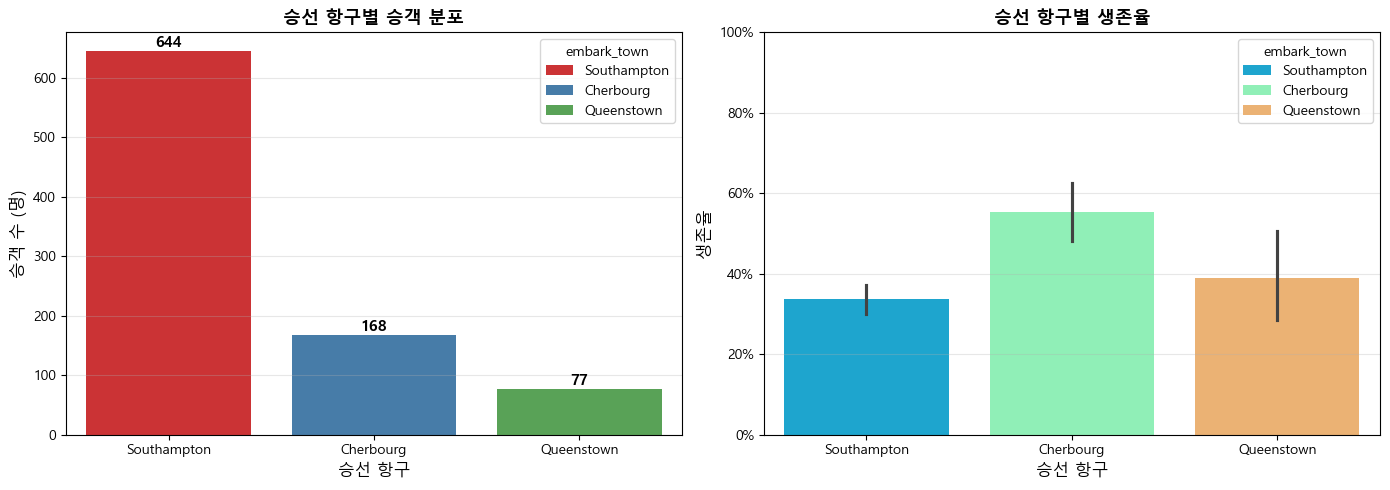

            survived           
                mean  sum count
embark_town                    
Cherbourg      0.554   93   168
Queenstown     0.390   30    77
Southampton    0.337  217   644


In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌측: 항구별 승객 수
sns.countplot(data=titanic, x='embark_town', ax=axes[0], palette='Set1', hue='embark_town')

for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11, fontweight='bold')

axes[0].set_xlabel('승선 항구', fontsize=12)
axes[0].set_ylabel('승객 수 (명)', fontsize=12)
axes[0].set_title('승선 항구별 승객 분포', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# 우측: 항구별 생존율
sns.barplot(data=titanic, x='embark_town', y='survived', ax=axes[1], palette='rainbow', hue='embark_town')

axes[1].set_xlabel('승선 항구', fontsize=12)
axes[1].set_ylabel('생존율', fontsize=12)
axes[1].set_title('승선 항구별 생존율', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_yticklabels([f'{int(y*100)}%' for y in axes[1].get_yticks()])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 상세 분석
embark_stats = titanic.groupby('embark_town').agg({
    'survived': ['mean', 'sum', 'count']
}).round(3)
print(embark_stats)

#  인사이트: Cherbourg 승선객이 생존율 55% (Southampton 34% 대비 1.6배)
#  Cherbourg는 1등급 비율 높음 → 등급이 생존율 차이의 주요 변수

# 각 범주형 변수별 생존율 계산

In [123]:
factors = {
    '성별(여성)': titanic[titanic['sex']=='female']['survived'].mean(),
    '성별(남성)': titanic[titanic['sex']=='male']['survived'].mean(),
    '1등급': titanic[titanic['class']=='First']['survived'].mean(),
    '3등급': titanic[titanic['class']=='Third']['survived'].mean(),
    '어린이(<10세)': titanic[titanic['age']<10]['survived'].mean(),
    '성인(30-50세)': titanic[(titanic['age']>=30) & (titanic['age']<50)]['survived'].mean(),
    '시니어(60세이상)' :titanic[titanic['age']>=60]['survived'].mean()
}

factors_df = pd.DataFrame(list(factors.items()), columns=['요인', '생존율'])
factors_df.sort_values(by=['생존율'], ascending=False)

,요인,생존율
0,성별(여성),0.742038
2,1등급,0.629630
4,어린이(<10세),0.612903
5,성인(30-50세),0.417969
6,시니어(60세이상),0.269231
3,3등급,0.242363
1,성별(남성),0.188908


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(factors_df['요인'], factors_df['생존율'])

# # 수치 표시
# for i, (factor, rate) in enumerate(zip(factors_df['요인'], factors_df['생존율'])):
#     ax.text(rate + 0.02, i, f'{rate*100:.1f}%', 
#             va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('생존율', fontsize=12)
ax.set_ylabel('요인', fontsize=12)
ax.set_title('Titanic 생존 요인별 생존율 비교', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


# 상관관계와 산점도 분석

In [125]:
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [126]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [128]:
diamonds_sample = diamonds.sample(1000, random_state=42)
diamonds_sample.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1388,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
50052,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
41645,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
42377,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
17244,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


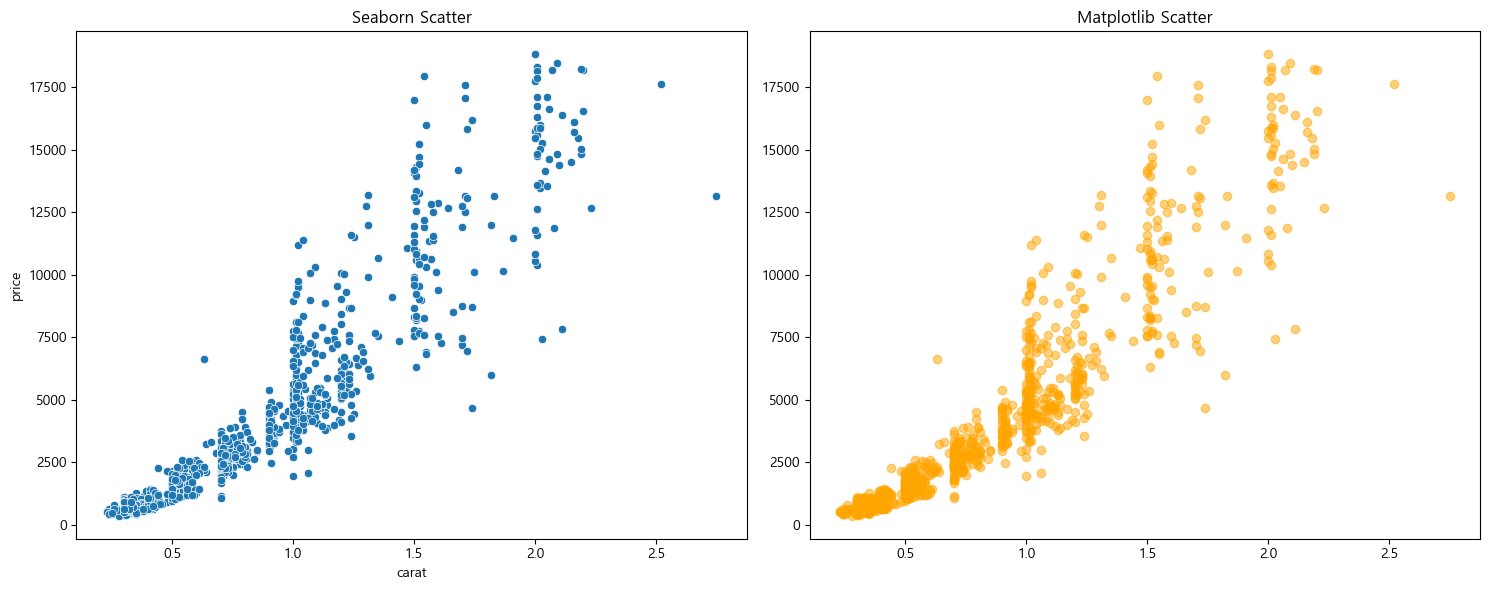

In [146]:
# 산점도.. scatter 캐럿이 가격에 미치는 영향
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=diamonds_sample, x='carat', y='price', ax=ax[0])
ax[0].set_title('Seaborn Scatter')

# 2. 두 번째 칸 (ax[1]): Matplotlib 기본 산점도
ax[1].scatter(diamonds_sample['carat'], diamonds_sample['price'], alpha=0.5, color='orange')
ax[1].set_title('Matplotlib Scatter')

plt.tight_layout()
plt.show()

In [140]:
# 상관계수 계산
corr = diamonds['carat'].corr(diamonds['price'])
print(f'상관계수 : {corr:.3f}')

상관계수 : 0.922


np.float64(1.0)

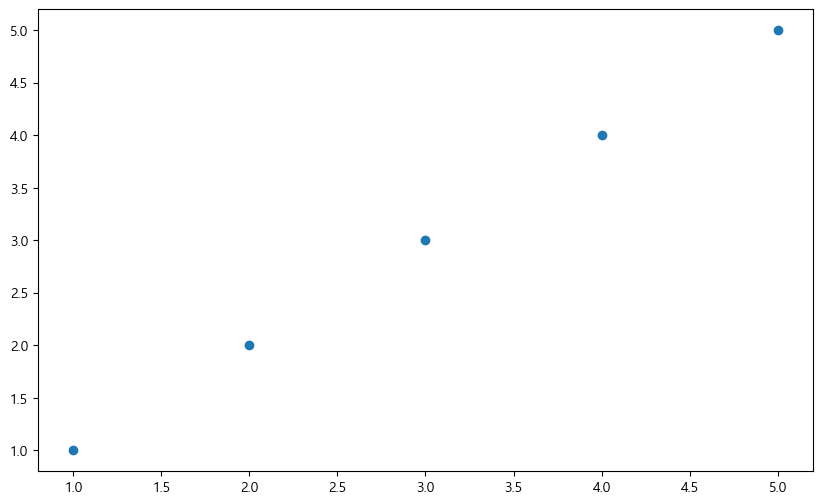

In [139]:
data = {
'x' : [1, 2, 3, 4, 5],
'y' : [1, 2, 3, 4, 5]
}
sample = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['x'], sample['y'])
round(sample['x'].corr(sample['y']), 3)

# [6교시]

<Axes: xlabel='carat', ylabel='price'>

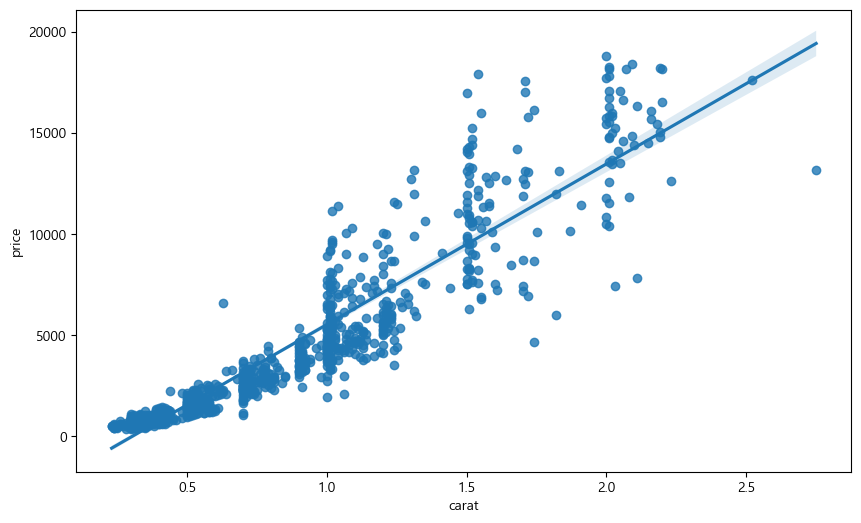

In [ ]:
# regplot : 회귀선
# 캐럿을 기준으로 적정 가격을 예측 할 수 있나?
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=diamonds_sample, x='carat', y='price', ax=ax)

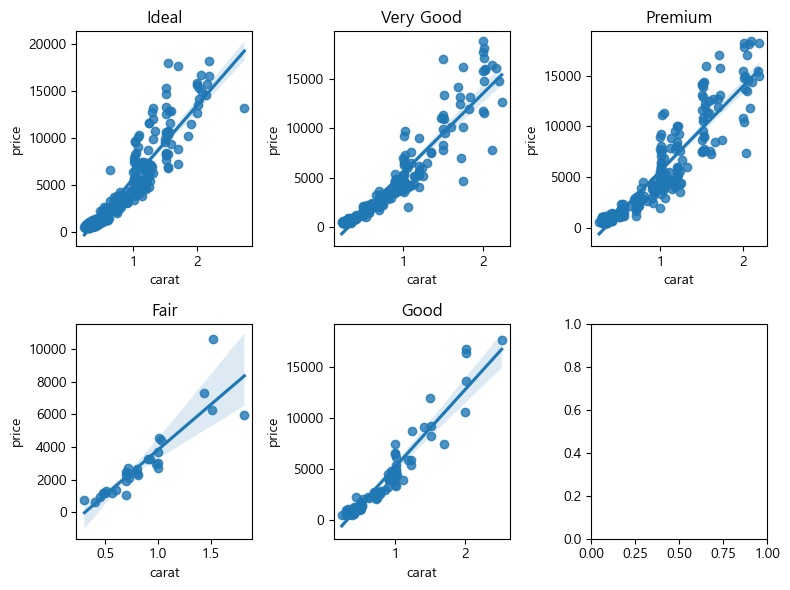

In [ ]:
# 다이아몬드 등급(커팅)에 따라 가격패턴이 다른가?
fig, ax = plt.subplots(2, 3, figsize=(8, 6))
for idx, cut in enumerate(diamonds_sample['cut'].unique() ):
    sns.regplot(data = diamonds_sample[diamonds_sample['cut'] == cut],
                    x='carat', y='price', ax = ax[idx//3, idx % 3])
    ax[idx // 3, idx % 3].set_title(cut)
plt.tight_layout()
plt.show()


# 투명도(clarity)별로 가격결정 패턴이 다른지 알아보기

       carat        cut color clarity  depth  table  price     x     y     z
1388    0.24      Ideal     G    VVS1   62.1   56.0    559  3.97  4.00  2.47
50052   0.58  Very Good     F    VVS2   60.0   57.0   2201  5.44  5.42  3.26
41645   0.40      Ideal     E    VVS2   62.1   55.0   1238  4.76  4.74  2.95
42377   0.43    Premium     E    VVS2   60.8   57.0   1304  4.92  4.89  2.98
17244   1.55      Ideal     E     SI2   62.3   55.0   6901  7.44  7.37  4.61
...      ...        ...   ...     ...    ...    ...    ...   ...   ...   ...
35207   0.33      Ideal     I      IF   61.6   55.0    891  4.47  4.46  2.75
15806   1.00      Ideal     E     SI1   62.4   55.0   6324  6.34  6.42  3.98
45884   0.58      Ideal     G     VS2   61.1   56.0   1719  5.40  5.43  3.31
22681   0.38      Ideal     J    VVS2   62.0   55.0    629  4.67  4.69  2.90
21429   1.18    Premium     G    VVS2   59.7   58.0   9537  6.94  6.90  4.13

[1000 rows x 10 columns]


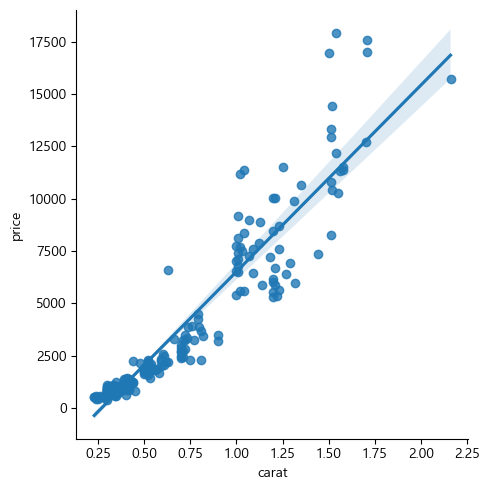

In [178]:
print(diamonds_sample)
diamonds_sample['clarity'].unique()

# ['IF', 'VVS1', 'VS1']
# diamonds_sample[diamonds_sample['clarity'] == 'IF']

clarity_subset = diamonds_sample[diamonds_sample['clarity'].isin(['IF', 'VVS1', 'VS1'])]
clarity_subset['clarity'].value_counts()
sns.lmplot(data = clarity_subset, x = 'carat', y = 'price')

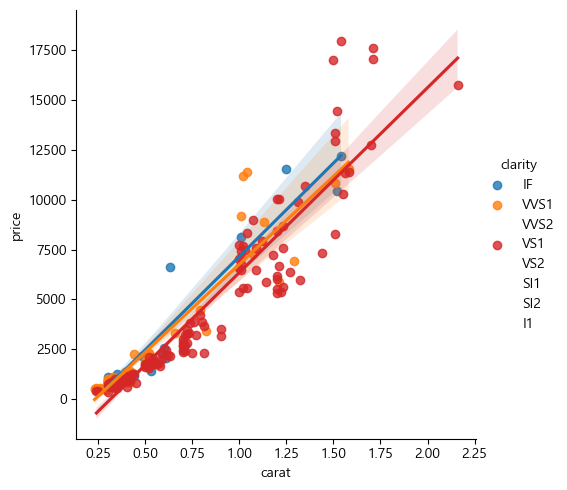

In [183]:
clarity_subset = diamonds_sample[diamonds_sample['clarity'].isin(['IF', 'VVS1', 'VS1'])]
g = sns.lmplot(data = clarity_subset, x='carat', y='price', hue='clarity')

<BarContainer object of 7 artists>

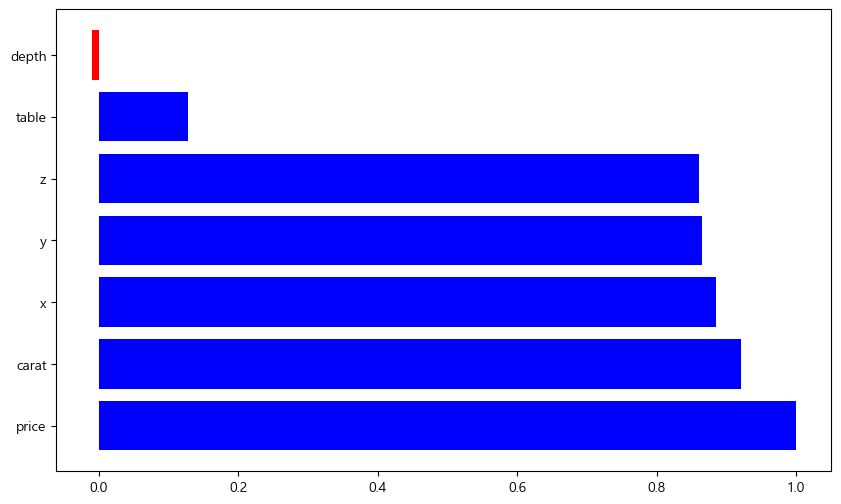

In [202]:
# 어떤 속성이 가격에 가장 큰 영향을 미칠까?
# 수치형 변수들의 상관계수를 계산
# print(diamonds_sample.describe())
numeric_cols = list(diamonds.describe().columns)
numeric_cols.remove('price')
collelation = diamonds[numeric_cols + ['price']].corr()['price'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
colors = [ 'blue' if x > 0 else 'red' for x in collelation.values]
ax.barh(collelation.index, collelation.values, color = colors)

# [7교시]

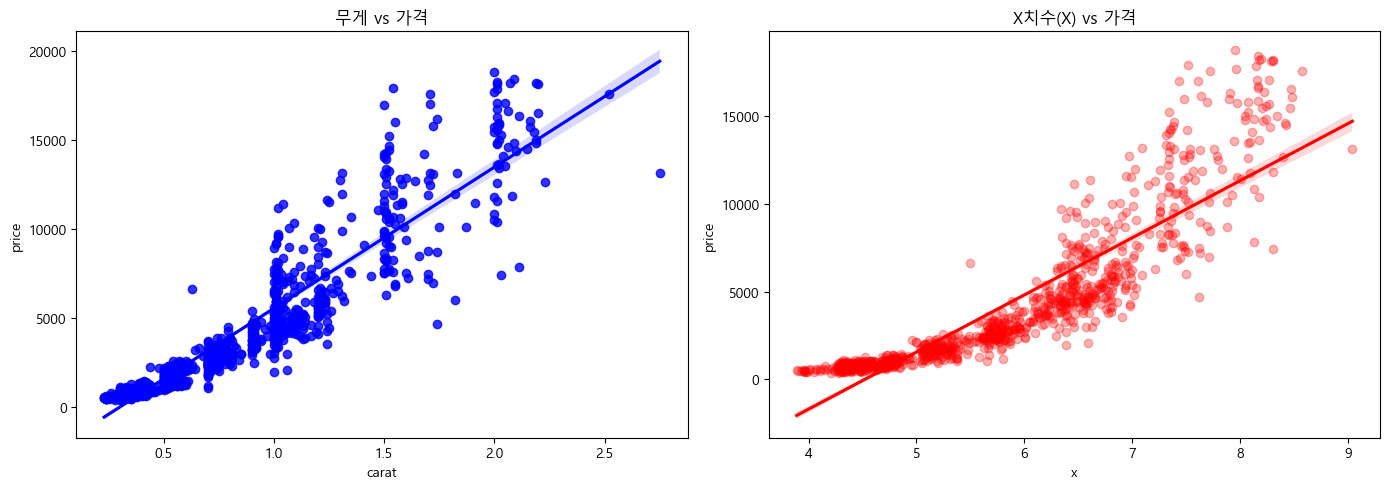

In [ ]:
# 상관관계 vs 인과관계
# 상관관계는 반드시 인과관계를 의미하지 않음
# 무게와 x 치수의 관계
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
# 좌측 carat vs price
sns.regplot(data = diamonds_sample, x='carat', y='price', ax=axes[0], color='blue')
axes[0].set_title('무게 vs 가격')
# 우측: X치수(x) vs price
sns.regplot(data=diamonds_sample, x='x', y='price', ax=axes[1], color='red', scatter_kws={'alpha':0.3})
axes[1].set_title('X치수(X) vs 가격')

plt.tight_layout()
plt.show()

# 무게가 증가하면 치수도 증가하는 관계 (치수 vs 가격 허위 상관관계)
# 추론할 때 불필요한 계수 즉 변수임.. 따라서 머신러닝 할 때는 학습에서 제외

In [ ]:
diamonds_sample[numeric_cols].corr()
# x, y, z컬럼의 carat부분이 중요하게 생각하는 가중치가 될 수 있다.

,carat,depth,table,x,y,z
carat,1.000000,-0.078646,0.200590,0.980120,0.979933,0.978572
depth,-0.078646,1.000000,-0.344625,-0.127685,-0.127643,-0.009381
table,0.200590,-0.344625,1.000000,0.218992,0.212593,0.177378
x,0.980120,-0.127685,0.218992,1.000000,0.998434,0.992165
y,0.979933,-0.127643,0.212593,0.998434,1.000000,0.992446
z,0.978572,-0.009381,0.177378,0.992165,0.992446,1.000000


# ------------------------------

In [ ]:
# heatmap 상관계술 매트릭스 시각화
# pairplot으로 전체 변수 관계 한눈에 파악
# 다변량 패턴 발견 및 변수 선택
# 옛날에 실제로 하나하나 길이를 재어서 데이터를 저장해놨다고 함..

iris = sns.load_dataset('iris')
iris['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [209]:
# 어떤 값들이 서로 연결되어 있나?
numeric_cols = iris.describe().columns
corr_matrix = iris[numeric_cols].corr()
corr_matrix.round(3)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


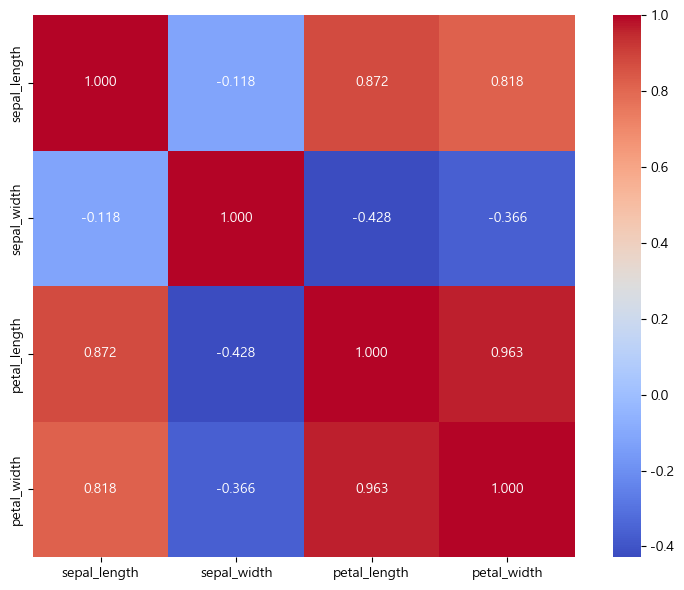

In [225]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(data=corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', ax=ax, square=True)
# labels = ['꽃받침길이', '꽃받침너비', '꽃잎길이', '꽃잎너비']
# ax.set_xticklabels(labels)
# ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

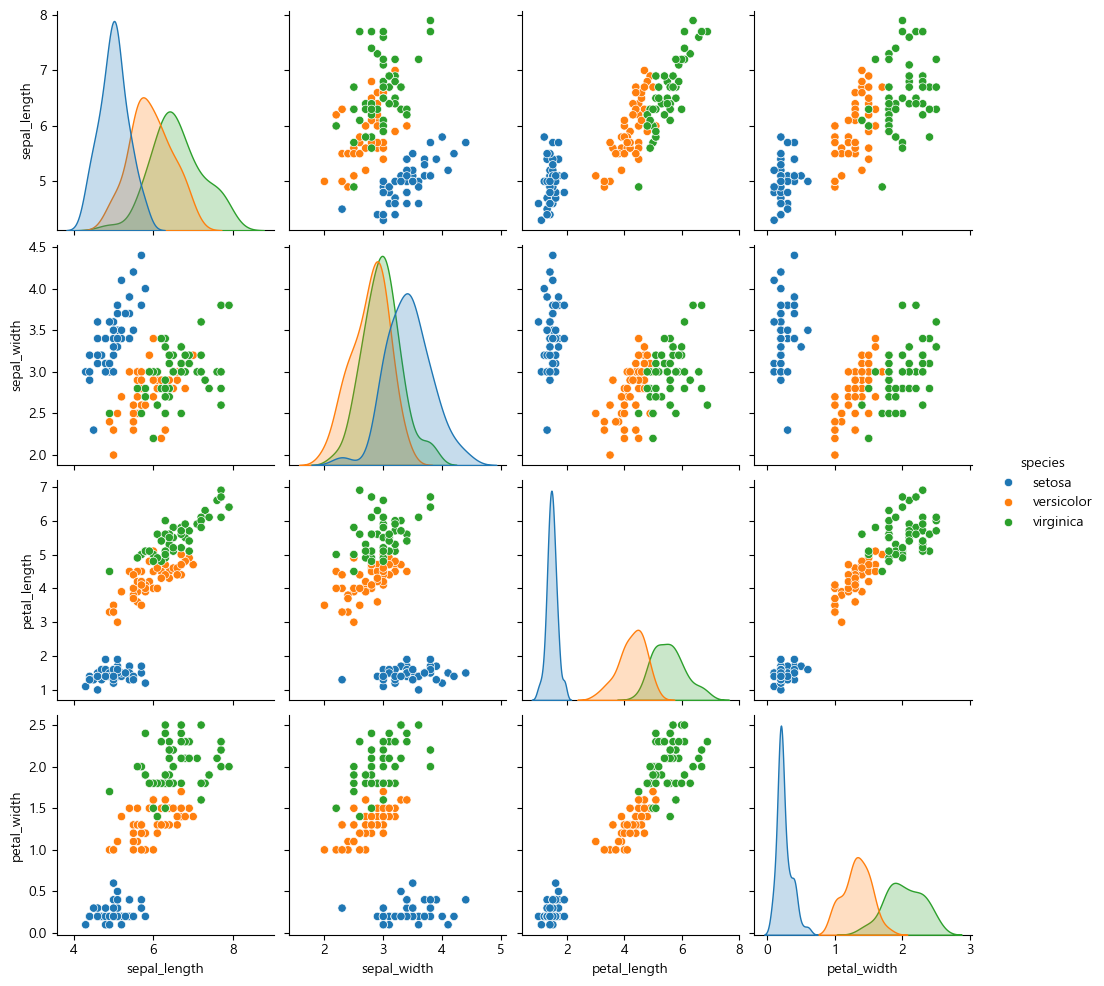

In [226]:
# 모든조합을 시각화 하는 pairplot이 있다.
sns.pairplot(iris, hue='species')

# [8교시]

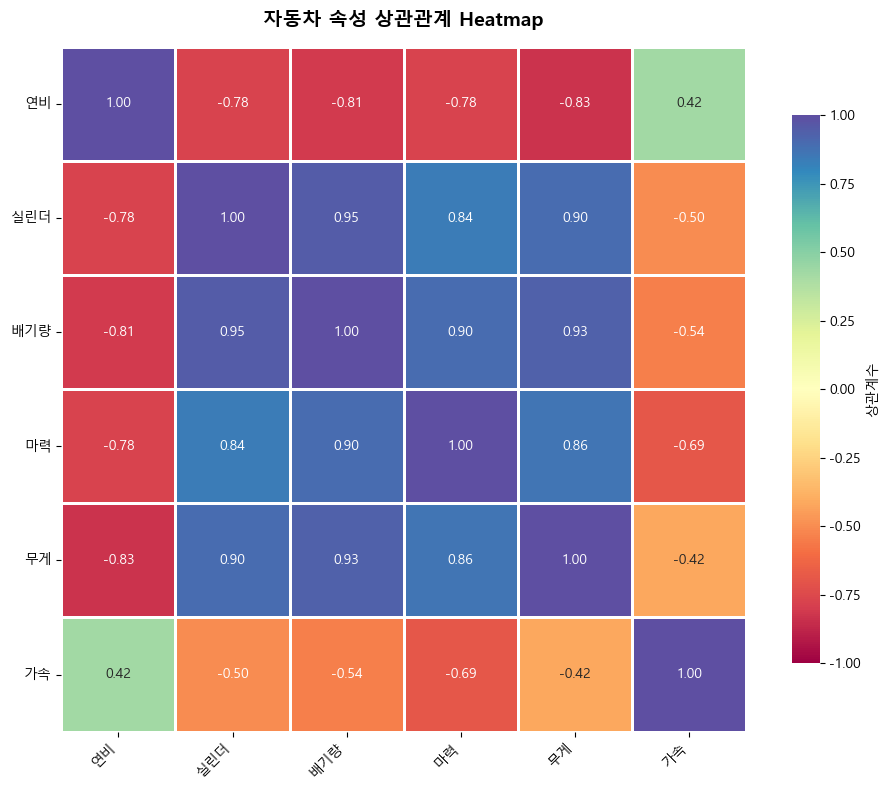


연비(mpg)와의 상관계수:
mpg             1.000000
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


In [230]:
# 자동차 데이터를 heatmap
# 연비향상 요인 분석 
# 1. 연비에 영향을 주는 변수들(상관관계 강한 양수 음수)
# 2. 연비에 영향을 주는 변수들끼리의 상관관계 - 다중공선성 문제( 서로 0.9이상 상관\
# 3. 연비와 약한 양의 상관관계 -> 독립적인 정보

# MPG 데이터 로드
mpg = sns.load_dataset('mpg')

# 수치형 변수만 선택
mpg_numeric = mpg[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']].dropna()
mpg_corr = mpg_numeric.corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap 생성
sns.heatmap(mpg_corr, annot=True, fmt='.2f', cmap='Spectral',
            center=0, square=True, linewidths=2, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': '상관계수'},
            ax=ax, vmin=-1, vmax=1)

ax.set_title('자동차 속성 상관관계 Heatmap', fontsize=14, fontweight='bold', pad=15)

# 레이블 한글화
mpg_labels = ['연비', '실린더', '배기량', '마력', '무게', '가속']
ax.set_xticklabels(mpg_labels, rotation=45, ha='right')
ax.set_yticklabels(mpg_labels, rotation=0)

plt.tight_layout()
plt.show()

# 강한 상관관계 추출
print("\n연비(mpg)와의 상관계수:")
print(mpg_corr['mpg'].sort_values(ascending=False))

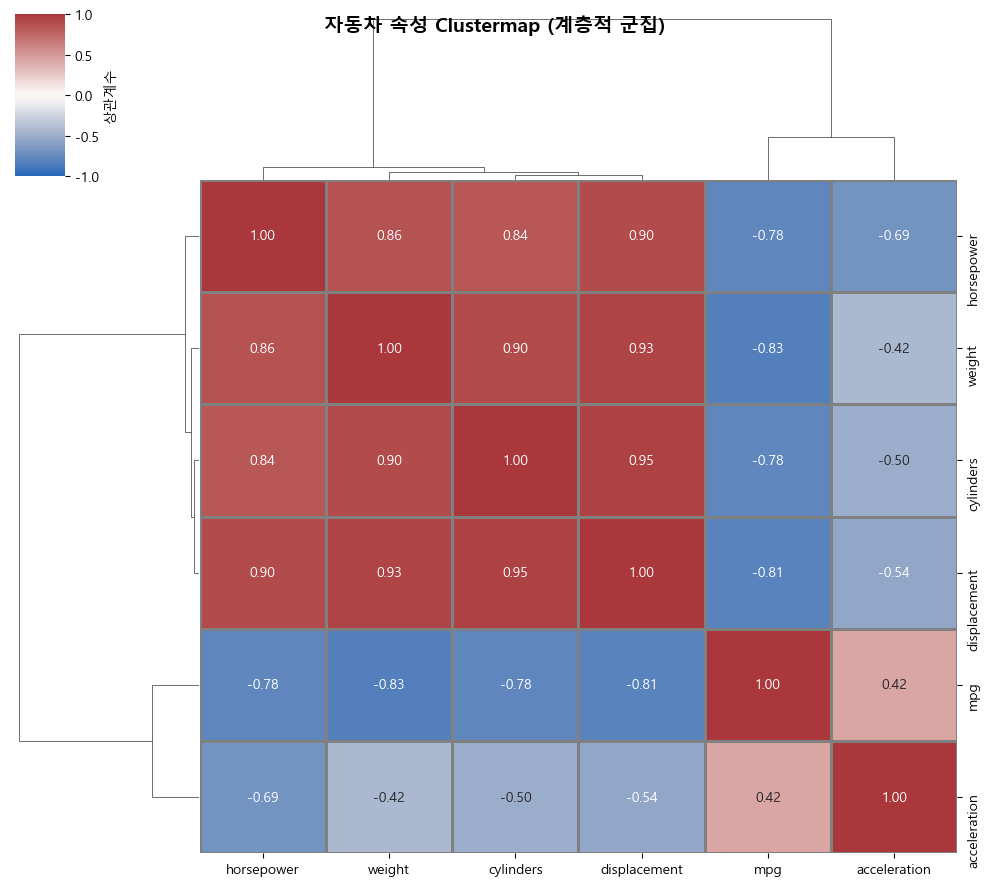

In [231]:
# 계층적 군집화 : ClusterMap
g = sns.clustermap(mpg_corr, annot=True, fmt='.2f', cmap='vlag',
                   center=0, linewidths=1, linecolor='gray',
                   cbar_kws={'label': '상관계수'},
                   figsize=(10, 9), vmin=-1, vmax=1)

g.fig.suptitle('자동차 속성 Clustermap (계층적 군집)', fontsize=14, fontweight='bold', y=0.98)

plt.show()

# -------------------------

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [233]:
flights = sns.load_dataset('flights')
flights.groupby('year')['month'].count()

year
1949    12
1950    12
1951    12
1952    12
1953    12
1954    12
1955    12
1956    12
1957    12
1958    12
1959    12
1960    12
Name: month, dtype: int64

In [234]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [235]:
# year + month - >datetime
flights['date'] =  flights['year'].astype(str) + '-' + flights['month'].astype(str) + '-01'
flights['date'] = pd.to_datetime(flights['date'])
flights = flights.sort_values(by='date').reset_index(drop=True)
flights['date']

0     1949-01-01
1     1949-02-01
2     1949-03-01
3     1949-04-01
4     1949-05-01
         ...    
139   1960-08-01
140   1960-09-01
141   1960-10-01
142   1960-11-01
143   1960-12-01
Name: date, Length: 144, dtype: datetime64[ns]

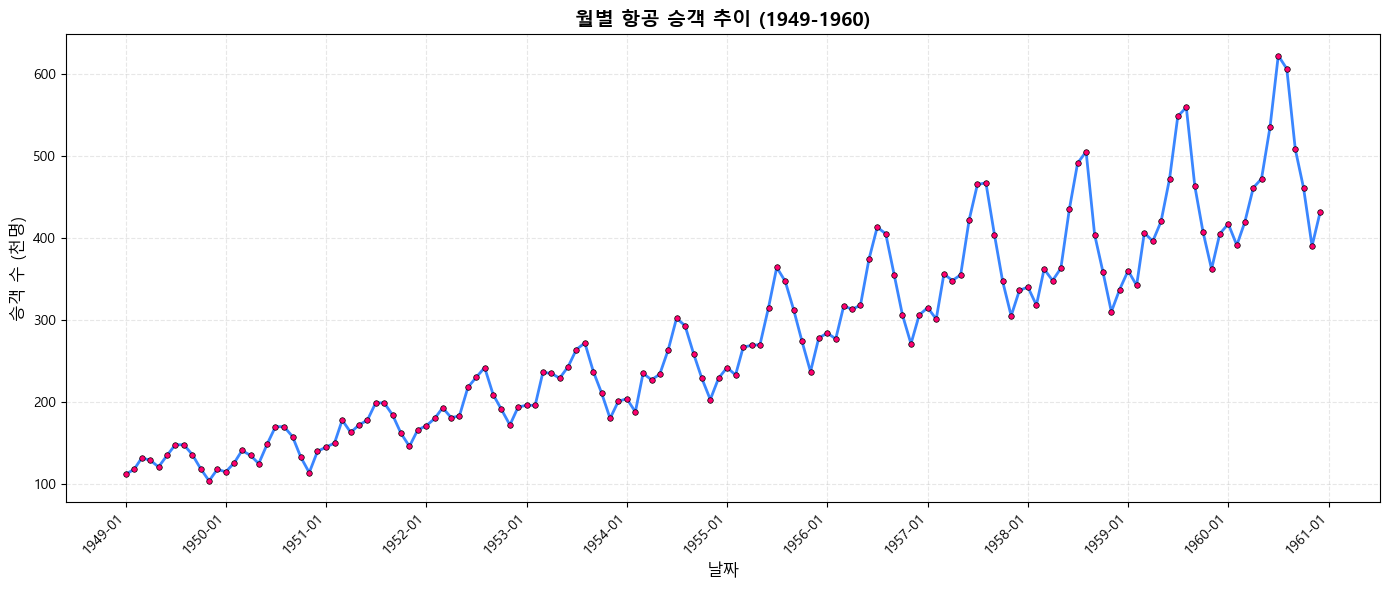

In [236]:
# 항공 승객수는 어떻게 변화했는지?
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(flights['date'], flights['passengers'], 
        linewidth=2, color='#3A86FF', marker='o', markersize=4,
        markerfacecolor='#FF006E', markeredgecolor='black', markeredgewidth=0.5)

ax.set_xlabel('날짜', fontsize=12)
ax.set_ylabel('승객 수 (천명)', fontsize=12)
ax.set_title('월별 항공 승객 추이 (1949-1960)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# X축 날짜 포맷팅
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 정리하며

## MPG 데이터 로드
mpg = sns.load_dataset('mpg')

## 수치형 변수만 선택
mpg_numeric = mpg[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']].dropna()
mpg_corr = mpg_numeric.corr()

fig, ax = plt.subplots(figsize=(10, 8))

## Heatmap 생성
sns.heatmap(mpg_corr, annot=True, fmt='.2f', cmap='Spectral',
            center=0, square=True, linewidths=2, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': '상관계수'},
            ax=ax, vmin=-1, vmax=1)

ax.set_title('자동차 속성 상관관계 Heatmap', fontsize=14, fontweight='bold', pad=15)

## 레이블 한글화
mpg_labels = ['연비', '실린더', '배기량', '마력', '무게', '가속']
ax.set_xticklabels(mpg_labels, rotation=45, ha='right')
ax.set_yticklabels(mpg_labels, rotation=0)

plt.tight_layout()
plt.show()

## 강한 상관관계 추출
print("\n연비(mpg)와의 상관계수:")
print(mpg_corr['mpg'].sort_values(ascending=False))
:thumbsup:
클릭해서 반응
:heart:
클릭해서 반응
:rofl:
클릭해서 반응
반응 추가하기
답장
전달
기타
g = sns.clustermap(mpg_corr, annot=True, fmt='.2f', cmap='vlag',
                   center=0, linewidths=1, linecolor='gray',
                   cbar_kws={'label': '상관계수'},
                   figsize=(10, 9), vmin=-1, vmax=1)

g.fig.suptitle('자동차 속성 Clustermap (계층적 군집)', fontsize=14, fontweight='bold', y=0.98)

plt.show()